# Balkendiagramm – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/balkendiagramm)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

Das **Balkendiagramm** (vertikal auch: Säulendiagramm) ist eines der am häufigsten
verwendeten Diagramme in wissenschaftlichen Arbeiten. Es wird eingesetzt um
**Häufigkeiten** oder **Mittelwerte** von Kategorien darzustellen.

| Variante | Beschreibung | Wann? |
|---|---|---|
| **Vertikal (Säulendiagramm)** | Balken stehen aufrecht, Kategorien auf x-Achse | Standard |
| **Horizontal** | Balken liegen waagerecht, Kategorien auf y-Achse | Viele/lange Labels |
| **Gruppiert** | Mehrere Balken je Kategorie (2 Variablen) | Gruppenvergleich |
| **Gestapelt** | Balken übereinander (100 % oder absolut) | Anteile je Gruppe |
| **Mit Fehlerbalken** | Balken + SD, SEM oder 95%-KI | Mittelwertvergleich |

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Beispieldaten (numiqo)

**Datensatz 1:** Automarken von Studierenden (kategorisch – für Häufigkeitsdiagramme)

**Datensatz 2:** Prüfungspunkte nach Kurs (metrisch + kategorisch – für Mittelwertdiagramme)

In [34]:
# Datensatz 1: Automarken (numiqo-Beispiel)
automarken = pd.Series(
    ["VW"]*14 + ["BMW"]*9 + ["Skoda"]*11 + ["Opel"]*7 + ["Daimler"]*5 +
    ["Audi"]*8 + ["Ford"]*6
)

# Datensatz 2: Prüfungspunkte nach Kurs und Geschlecht
kurse     = (["Kurs A"]*30 + ["Kurs B"]*30 + ["Kurs C"]*30)
punkte    = (
    list(np.random.normal(58, 10, 30)) +
    list(np.random.normal(67,  9, 30)) +
    list(np.random.normal(73,  8, 30))
)
geschlecht = (
    ["männlich"]*15 + ["weiblich"]*15 +
    ["männlich"]*15 + ["weiblich"]*15 +
    ["männlich"]*15 + ["weiblich"]*15
)
df = pd.DataFrame({"Kurs": kurse, "Punkte": punkte, "Geschlecht": geschlecht})
df["Punkte"] = df["Punkte"].clip(0, 100).round(1)

print(f"Datensatz 1 – Automarken:  {len(automarken)} Beobachtungen")
print(automarken.value_counts().to_string())
print()
print(f"Datensatz 2 – Prüfungspunkte:  {len(df)} Beobachtungen")
print(df.groupby("Kurs")["Punkte"].describe().round(2).to_string())

Datensatz 1 – Automarken:  60 Beobachtungen
VW         14
Skoda      11
BMW         9
Audi        8
Opel        7
Ford        6
Daimler     5

Datensatz 2 – Prüfungspunkte:  90 Beobachtungen
        count   mean   std   min    25%    50%    75%   max
Kurs                                                       
Kurs A   30.0  56.13  8.99  38.9  52.10  55.70  61.62  73.8
Kurs B   30.0  65.91  8.39  49.4  60.60  66.45  71.90  83.7
Kurs C   30.0  73.09  7.94  52.0  68.93  73.20  78.90  85.5


## 2. Einfaches Balkendiagramm – Häufigkeiten

Das einfachste Balkendiagramm zeigt die **absoluten oder relativen Häufigkeiten**
einer kategorischen Variable.

**Aufbau:**
- x-Achse (vertikal): Kategorien (Merkmalsausprägungen)
- y-Achse (vertikal): Häufigkeit oder Prozent
- Jeder Balken = eine Kategorie, Höhe proportional zur Häufigkeit
- **Abstand zwischen den Balken** (Unterschied zum Histogramm!)

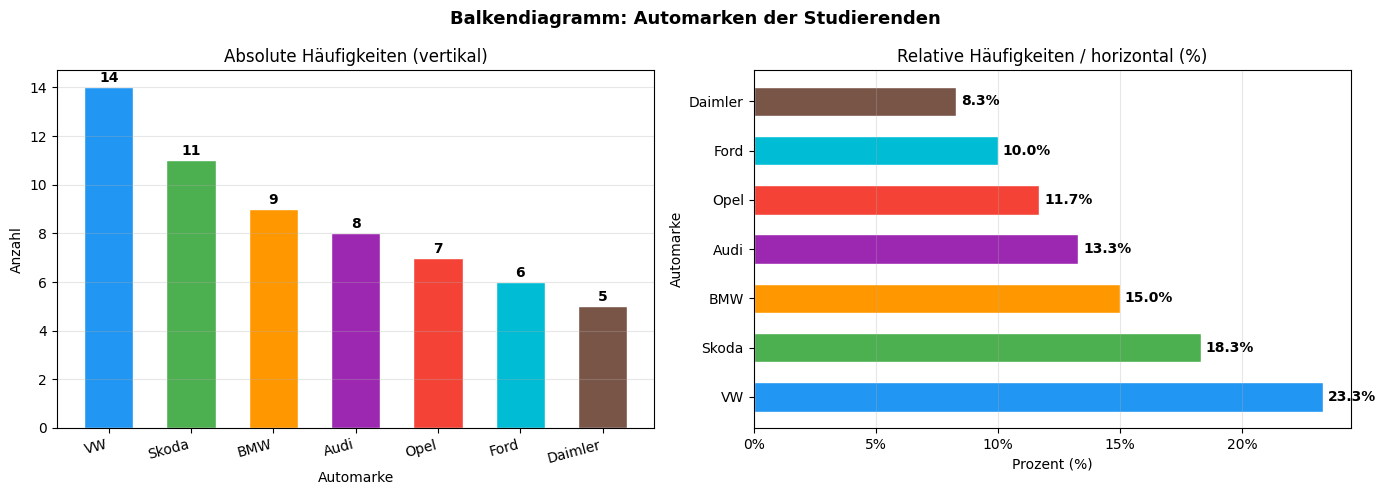

In [35]:
# Einfaches Balkendiagramm – Automarken (numiqo-Beispiel)
haeuf = automarken.value_counts().sort_values(ascending=False)
n_gesamt = len(automarken)
farben   = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#00BCD4","#795548"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Balkendiagramm: Automarken der Studierenden", fontsize=13, fontweight="bold")

# Absolut – vertikal
axes[0].bar(range(len(haeuf)), haeuf.values, color=farben, edgecolor="white", width=0.6)
axes[0].set_title("Absolute Häufigkeiten (vertikal)")
axes[0].set_xlabel("Automarke")
axes[0].set_ylabel("Anzahl")
axes[0].set_xticks(range(len(haeuf)))
axes[0].set_xticklabels(haeuf.index, rotation=15, ha="right")
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(haeuf.values):
    axes[0].text(i, v + 0.2, str(v), ha="center", fontweight="bold")

# Relativ – horizontal
rel = (haeuf / n_gesamt * 100).round(1)
axes[1].barh(range(len(rel)), rel.values, color=farben, edgecolor="white", height=0.6)
axes[1].set_title("Relative Häufigkeiten / horizontal (%)")
axes[1].set_xlabel("Prozent (%)")
axes[1].set_ylabel("Automarke")
axes[1].set_yticks(range(len(rel)))
axes[1].set_yticklabels(rel.index)
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[1].grid(axis="x", alpha=0.3)
for i, v in enumerate(rel.values):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 3. Gruppiertes Balkendiagramm

Liegen **zwei kategorische Variablen** vor, können **gruppierte Balkendiagramme**
erstellt werden.

- Die **Gruppen** ergeben sich aus den Kategorien einer Variable
- Die zweite Variable wird durch **unterschiedliche Farben** dargestellt
- Es können absolute Häufigkeiten, Prozente oder Mittelwerte abgebildet werden

**Beispiel numiqo:** Automarke + Geschlecht – blaue Balken für Männer, orange für Frauen.

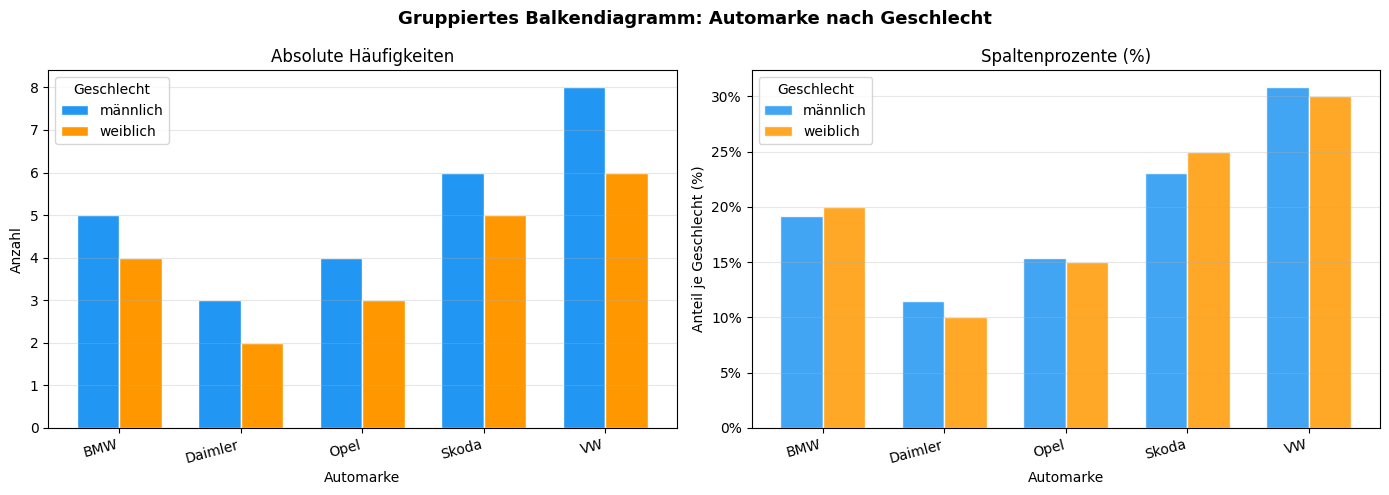

In [36]:
# Gruppiertes Balkendiagramm – Automarken nach Geschlecht (numiqo-Beispiel)
np.random.seed(7)
automarken_2 = pd.Series(
    ["VW"]*8  + ["BMW"]*5  + ["Skoda"]*6 + ["Opel"]*4 + ["Daimler"]*3 +
    ["VW"]*6  + ["BMW"]*4  + ["Skoda"]*5 + ["Opel"]*3 + ["Daimler"]*2
)
geschlecht_auto = ["maennlich"]*26 + ["weiblich"]*20
df_auto = pd.DataFrame({"Automarke": automarken_2, "Geschlecht": geschlecht_auto})

kt = pd.crosstab(df_auto["Automarke"], df_auto["Geschlecht"])
marken      = kt.index.tolist()
x           = np.arange(len(marken))
breite      = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gruppiertes Balkendiagramm: Automarke nach Geschlecht", fontsize=13, fontweight="bold")

# Absolut
axes[0].bar(x - breite/2, kt["maennlich"], breite,
            label="männlich", color="#2196F3", edgecolor="white")
axes[0].bar(x + breite/2, kt["weiblich"],  breite,
            label="weiblich",  color="#FF9800", edgecolor="white")
axes[0].set_title("Absolute Häufigkeiten")
axes[0].set_xlabel("Automarke")
axes[0].set_ylabel("Anzahl")
axes[0].set_xticks(x)
axes[0].set_xticklabels(marken, rotation=15, ha="right")
axes[0].legend(title="Geschlecht")
axes[0].grid(axis="y", alpha=0.3)

# Prozente innerhalb Geschlecht (Spaltenprozente)
kt_proz = kt.div(kt.sum(axis=0), axis=1).mul(100).round(1)
axes[1].bar(x - breite/2, kt_proz["maennlich"], breite,
            label="männlich", color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].bar(x + breite/2, kt_proz["weiblich"],  breite,
            label="weiblich",  color="#FF9800", edgecolor="white", alpha=0.85)
axes[1].set_title("Spaltenprozente (%)")
axes[1].set_xlabel("Automarke")
axes[1].set_ylabel("Anteil je Geschlecht (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(marken, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[1].legend(title="Geschlecht")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Gestapeltes Balkendiagramm

Im **gestapelten Balkendiagramm** werden die Balken übereinander gelegt.
Es gibt zwei Varianten:

| Variante | Beschreibung | Wann? |
|---|---|---|
| **Absolut gestapelt** | Gesamthöhe = Summe aller Teilwerte | Absolute Zahlen vergleichen |
| **100 % gestapelt** | Alle Balken gleich hoch (100 %) | Anteile je Gruppe vergleichen |

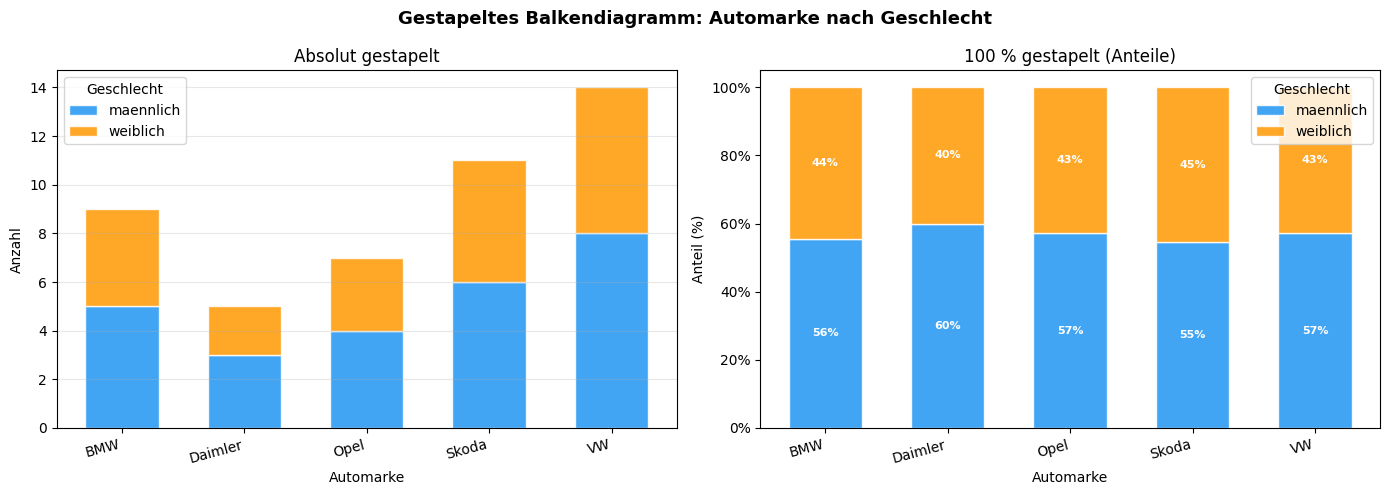

In [37]:
# Gestapeltes Balkendiagramm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gestapeltes Balkendiagramm: Automarke nach Geschlecht", fontsize=13, fontweight="bold")

farben_g = {"maennlich": "#2196F3", "weiblich": "#FF9800"}

# Absolut gestapelt
unten = np.zeros(len(marken))
for geschl, farbe in farben_g.items():
    axes[0].bar(range(len(marken)), kt[geschl].values,
                bottom=unten, label=geschl,
                color=farbe, edgecolor="white", width=0.6, alpha=0.85)
    unten += kt[geschl].values
axes[0].set_title("Absolut gestapelt")
axes[0].set_xlabel("Automarke")
axes[0].set_ylabel("Anzahl")
axes[0].set_xticks(range(len(marken)))
axes[0].set_xticklabels(marken, rotation=15, ha="right")
axes[0].legend(title="Geschlecht")
axes[0].grid(axis="y", alpha=0.3)

# 100 % gestapelt
kt_100 = kt.div(kt.sum(axis=1), axis=0).mul(100)
unten2 = np.zeros(len(marken))
for geschl, farbe in farben_g.items():
    axes[1].bar(range(len(marken)), kt_100[geschl].values,
                bottom=unten2, label=geschl,
                color=farbe, edgecolor="white", width=0.6, alpha=0.85)
    for i, (val, u) in enumerate(zip(kt_100[geschl].values, unten2)):
        if val > 6:
            axes[1].text(i, u + val/2, f"{val:.0f}%",
                         ha="center", va="center", fontsize=8,
                         color="white", fontweight="bold")
    unten2 += kt_100[geschl].values
axes[1].set_title("100 % gestapelt (Anteile)")
axes[1].set_xlabel("Automarke")
axes[1].set_ylabel("Anteil (%)")
axes[1].set_xticks(range(len(marken)))
axes[1].set_xticklabels(marken, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[1].legend(title="Geschlecht")

plt.tight_layout()
plt.show()

## 5. Balkendiagramm für Mittelwerte

Neben Häufigkeiten können Balkendiagramme auch **Mittelwerte** darstellen –
dafür braucht man eine **kategorische** und eine **metrische Variable**.

### Fehlerbalken

**Fehlerbalken** zeigen die Streuung der Daten und geben Auskunft über die
Genauigkeit der Messung. Sie werden als vertikale Linien über und unter dem Balken
eingezeichnet und können berechnet werden über:

| Fehlermaß | Bedeutung | Formel |
|---|---|---|
| **Standardabweichung (SD)** | Streuung der Rohdaten | $s$ |
| **Standardfehler (SEM)** | Genauigkeit des Mittelwerts | $s / \sqrt{n}$ |
| **95%-Konfidenzintervall** | Bereich für den wahren Mittelwert | $\bar{x} \pm 1{,}96 \times SEM$ |

Zusammenfassung: Prüfungspunkte je Kurs
  Kurs  Mittelwert   SD  n  SEM  KI95
Kurs A       56.13 8.99 30 1.64  3.22
Kurs B       65.91 8.39 30 1.53  3.00
Kurs C       73.09 7.94 30 1.45  2.84


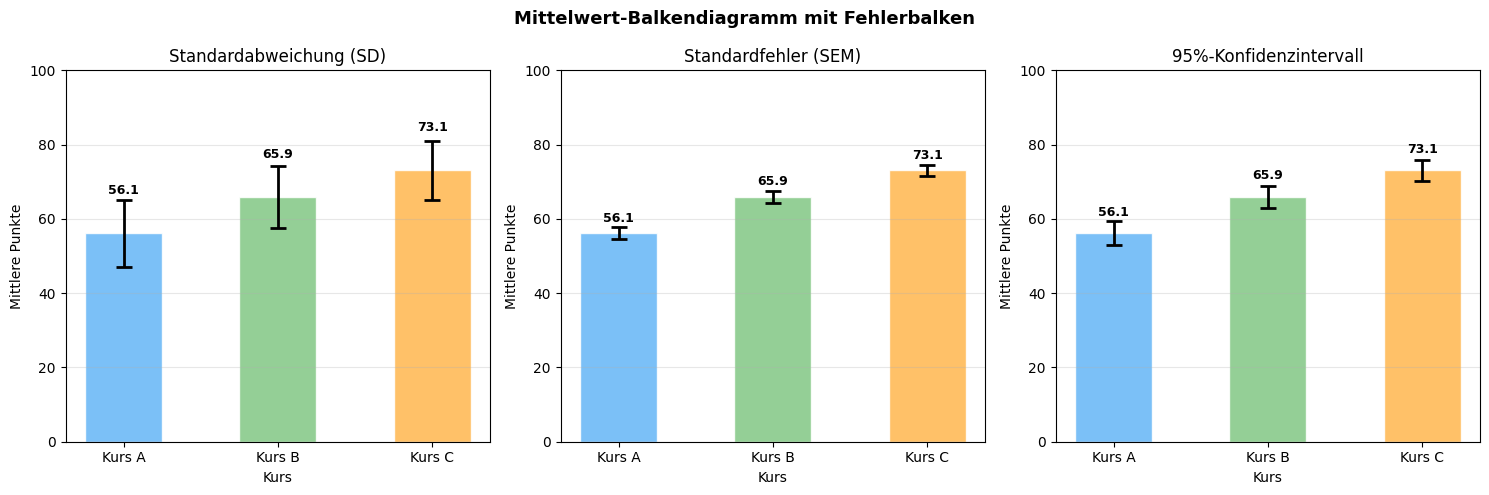

In [38]:
# Mittelwert-Balkendiagramm mit Fehlerbalken
zusammenfassung = df.groupby("Kurs")["Punkte"].agg(
    Mittelwert="mean",
    SD="std",
    n="count"
).reset_index()
zusammenfassung["SEM"] = zusammenfassung["SD"] / np.sqrt(zusammenfassung["n"])
zusammenfassung["KI95"] = zusammenfassung["SEM"] * 1.96

print("Zusammenfassung: Prüfungspunkte je Kurs")
print(zusammenfassung.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Mittelwert-Balkendiagramm mit Fehlerbalken", fontsize=13, fontweight="bold")

farben_kurse = ["#64B5F6", "#81C784", "#FFB74D"]
fehler_arten = [
    ("SD",   "Standardabweichung (SD)"),
    ("SEM",  "Standardfehler (SEM)"),
    ("KI95", "95%-Konfidenzintervall"),
]

for ax, (fehler_col, titel) in zip(axes, fehler_arten):
    ax.bar(range(len(zusammenfassung)), zusammenfassung["Mittelwert"],
           color=farben_kurse, edgecolor="white", width=0.5, alpha=0.85)
    ax.errorbar(range(len(zusammenfassung)), zusammenfassung["Mittelwert"],
                yerr=zusammenfassung[fehler_col],
                fmt="none", color="black", capsize=6, capthick=2, linewidth=2)
    ax.set_title(titel)
    ax.set_xlabel("Kurs")
    ax.set_ylabel("Mittlere Punkte")
    ax.set_xticks(range(len(zusammenfassung)))
    ax.set_xticklabels(zusammenfassung["Kurs"])
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)
    for i, row in zusammenfassung.iterrows():
        ax.text(i, row["Mittelwert"] + zusammenfassung[fehler_col].max() + 1.5,
                f"{row['Mittelwert']:.1f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Gruppiertes Mittelwert-Balkendiagramm

Mit zwei Variablen (Kurs + Geschlecht) entsteht ein **gruppiertes
Mittelwert-Balkendiagramm** – das entspricht genau dem numiqo-Beispiel mit
blauen (männlich) und orangen (weiblich) Balken.

Vorhandene Geschlechter-Werte: ['männlich' 'weiblich']
Vorhandene Kurs-Werte:         ['Kurs A' 'Kurs B' 'Kurs C']

Aggregierte Tabelle:
  Kurs Geschlecht        mw       sd  n      sem
Kurs A   männlich 58.113333 9.930031 15 2.563923
Kurs A   weiblich 54.146667 7.777519 15 2.008147
Kurs B   männlich 64.553333 9.164673 15 2.366308
Kurs B   weiblich 67.266667 7.596396 15 1.961381
Kurs C   männlich 73.333333 9.266427 15 2.392581
Kurs C   weiblich 72.853333 6.672103 15 1.722729



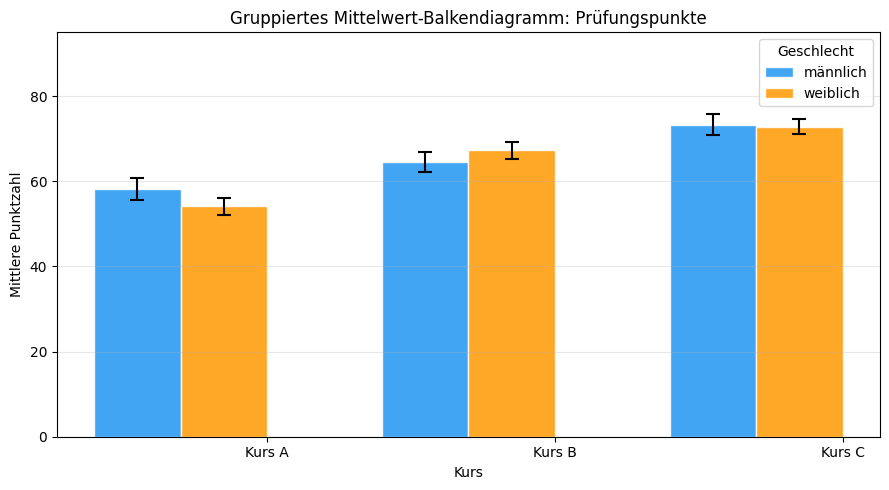

In [39]:
# Gruppiertes Mittelwert-Balkendiagramm: Kurs x Geschlecht
grp = df.groupby(["Kurs", "Geschlecht"])["Punkte"].agg(
    mw="mean", sd="std", n="count"
).reset_index()
grp["sem"] = grp["sd"] / np.sqrt(grp["n"])

# Tatsächliche Werte prüfen (Bsp: grp[grp["Geschlecht"] == geschl] kann eine leere Teilmenge zurückgeben)
print("Vorhandene Geschlechter-Werte:", df["Geschlecht"].unique())
print("Vorhandene Kurs-Werte:        ", df["Kurs"].unique())
print()

grp = df.groupby(["Kurs", "Geschlecht"])["Punkte"].agg(
    mw="mean", sd="std", n="count"
).reset_index()
grp["sem"] = grp["sd"] / np.sqrt(grp["n"])

print("Aggregierte Tabelle:")
print(grp.to_string(index=False))
print()

kurse_u    = sorted(grp["Kurs"].unique())
geschl_u   = sorted(["männlich", "weiblich"])
x          = np.arange(len(kurse_u))
breite     = 0.6 / len(geschl_u)
farben_mw  = dict(zip(geschl_u, ["#2196F3", "#FF9800", "#4CAF50"]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title("Gruppiertes Mittelwert-Balkendiagramm: Prüfungspunkte", fontsize=12)

for idx, geschl in enumerate(geschl_u):
    teilmenge = grp[grp["Geschlecht"] == geschl].set_index("Kurs").reindex(kurse_u)
    offset    = (idx - (len(geschl_u) - 1 / 2)) * breite
    ax.bar(x + offset, teilmenge["mw"].values, breite,
                  label=geschl, color=farben_mw[geschl],
                  edgecolor="white", alpha=0.85)
    ax.errorbar(x + offset, teilmenge["mw"].values,
                yerr=teilmenge["sem"].values,
                fmt="none", color="black", capsize=5, capthick=1.5, linewidth=1.5)

ax.set_xlabel("Kurs")
ax.set_ylabel("Mittlere Punktzahl")
ax.set_xticks(x)
ax.set_xticklabels(kurse_u)
ax.set_ylim(0, 95)
ax.legend(title="Geschlecht")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Tipps: Sortierung, Beschriftung und Gestaltung

Gute Balkendiagramme folgen einigen einfachen Regeln:

| Tipp | Warum? |
|---|---|
| **Absteigend sortieren** | Rangreihenfolge sofort sichtbar |
| **Datenwerte beschriften** | Exakte Werte ohne Ablesen |
| **y-Achse bei 0 beginnen** | Keine optische Verzerrung |
| **Nicht zu viele Farben** | Max. 5–7 Kategorien je Diagramm |
| **Gitter dezent** | Orientierung ohne Ablenkung |

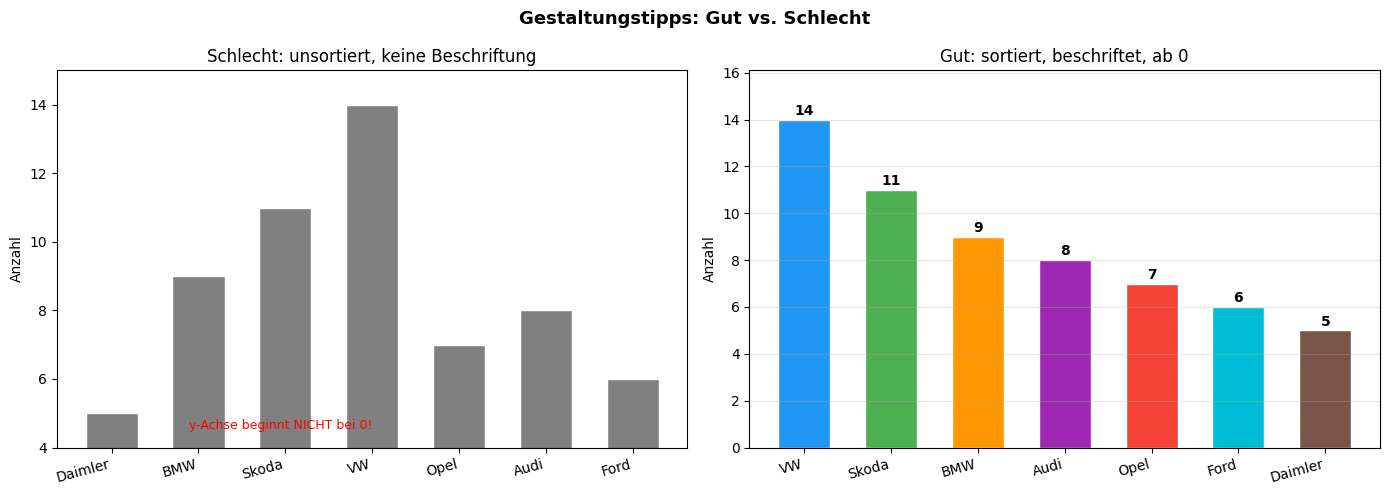

In [40]:
# Gutes vs. schlechtes Balkendiagramm
haeuf_sorted   = haeuf.sort_values(ascending=False)
haeuf_unsorted = haeuf.sample(frac=1, random_state=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gestaltungstipps: Gut vs. Schlecht", fontsize=13, fontweight="bold")

# Schlecht: unsortiert, keine Beschriftung, Achse nicht bei 0
axes[0].bar(range(len(haeuf_unsorted)), haeuf_unsorted.values,
            color="gray", edgecolor="white", width=0.6)
axes[0].set_title("Schlecht: unsortiert, keine Beschriftung")
axes[0].set_xticks(range(len(haeuf_unsorted)))
axes[0].set_xticklabels(haeuf_unsorted.index, rotation=15, ha="right")
axes[0].set_ylim(4, 15)   # y-Achse beginnt nicht bei 0 – verzerrt!
axes[0].set_ylabel("Anzahl")
axes[0].annotate("y-Achse beginnt NICHT bei 0!", xy=(0.5, 0.05),
                 xycoords="axes fraction", ha="right", color="red", fontsize=9)

# Gut: sortiert, beschriftet, ab 0, Farben
axes[1].bar(range(len(haeuf_sorted)), haeuf_sorted.values,
            color=farben[:len(haeuf_sorted)], edgecolor="white", width=0.6)
axes[1].set_title("Gut: sortiert, beschriftet, ab 0")
axes[1].set_xticks(range(len(haeuf_sorted)))
axes[1].set_xticklabels(haeuf_sorted.index, rotation=15, ha="right")
axes[1].set_ylim(0, haeuf_sorted.max() * 1.15)
axes[1].set_ylabel("Anzahl")
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(haeuf_sorted.values):
    axes[1].text(i, v + 0.2, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 8. Zusammenfassung

```
Balkendiagramm – Varianten und Einsatz
│
├── EINFACH (1 kategorische Variable)
│   ├── Vertikal  → ax.bar()   – Standard
│   └── Horizontal → ax.barh() – bei langen Labels
│
├── GRUPPIERT (2 kategorische Variablen)
│   └── ax.bar() mit versetzten x-Positionen (offset)
│       Farben = zweite Variable
│
├── GESTAPELT (2 kategorische Variablen)
│   ├── Absolut  → bottom-Parameter
│   └── 100 %    → Anteile je Gruppe sichtbar
│
├── MITTELWERTE (1 kategorisch + 1 metrisch)
│   └── Mit Fehlerbalken: ax.errorbar()
│       SD  = Streuung der Rohdaten
│       SEM = s / sqrt(n)  – Genauigkeit des MW
│       KI  = 1.96 x SEM   – 95%-Bereich
│
└── GESTALTUNGSTIPPS
    ├── Absteigend sortieren
    ├── y-Achse immer bei 0 beginnen
    ├── Datenwerte beschriften
    └── Max. 5–7 Kategorien
```

| Variante | Python | Wann? |
|---|---|---|
| Vertikal | `ax.bar(x, y)` | Standard |
| Horizontal | `ax.barh(y, x)` | Lange Labels |
| Gruppiert | `ax.bar(x+offset, y)` | 2 Variablen |
| Gestapelt | `ax.bar(x, y, bottom=...)` | Anteile |
| Fehlerbalken | `ax.errorbar(x, y, yerr=...)` | Mittelwerte |

---
Quelle: [numiqo.de/tutorial/balkendiagramm](https://numiqo.de/tutorial/balkendiagramm)